In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms
from torchvision import datasets

import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [4]:
train_Dataset = datasets.MNIST(root='./dataset', train=True, download=True, transform=transforms.ToTensor())

In [5]:
test_Dataset = datasets.MNIST(root='./dataset', train=False, download=True, transform=transforms.ToTensor())

In [38]:
class MNISTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            # nn.Linear(256, 128),
            # nn.ReLU(),
            nn.Linear(128, 10)
        )
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        logits = self.linear_relu_stack(x)
        return logits

In [39]:
model=MNISTModel()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=1e-3)

In [40]:
train_dataloader = DataLoader(train_Dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_Dataset, batch_size=64, shuffle=False)

In [26]:
print("Model device:", next(model.parameters()).device)


Model device: cpu


In [41]:
epochs = 20
model.train().to(device)
for epoch in range(epochs):
    print(f"Epoch {epoch+1}\n-------------------------------")
    
    total_loss = 0

    for batch, (images,labels) in enumerate(train_dataloader):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(images)
        loss = loss_fn(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"end=of epoch {epoch+1}, loss: {total_loss/len(train_dataloader)},device: {next(model.parameters()).device}")

Epoch 1
-------------------------------
end=of epoch 1, loss: 2.2337425288869373,device: cuda:0
Epoch 2
-------------------------------
end=of epoch 2, loss: 2.0371365937342776,device: cuda:0
Epoch 3
-------------------------------
end=of epoch 3, loss: 1.7709705449624864,device: cuda:0
Epoch 4
-------------------------------
end=of epoch 4, loss: 1.4712980342572177,device: cuda:0
Epoch 5
-------------------------------
end=of epoch 5, loss: 1.201774589987452,device: cuda:0
Epoch 6
-------------------------------
end=of epoch 6, loss: 1.0004549212038898,device: cuda:0
Epoch 7
-------------------------------
end=of epoch 7, loss: 0.8600831743496568,device: cuda:0
Epoch 8
-------------------------------
end=of epoch 8, loss: 0.7619259202404063,device: cuda:0
Epoch 9
-------------------------------
end=of epoch 9, loss: 0.6906680977865577,device: cuda:0
Epoch 10
-------------------------------
end=of epoch 10, loss: 0.6371991374790033,device: cuda:0
Epoch 11
------------------------------

In [29]:
print(len(train_dataloader))

938


In [42]:
model.eval()
correct=0
index = 0
with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)
        output = model(images)
        pred = output.argmax(dim=1, keepdim=True)
        correct = pred.eq(labels.view_as(pred)).sum().item()
    accuracy = correct / len(labels)
    print(f"Accuracy: {accuracy*100:.2f}%")

Accuracy: 100.00%


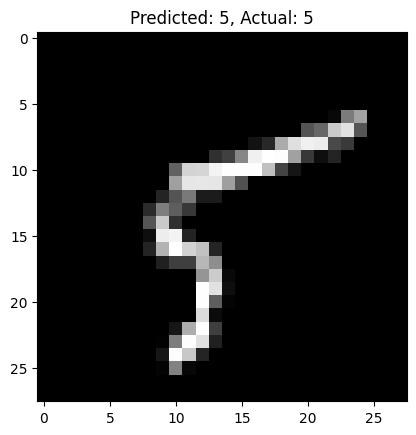

In [53]:
index=59
with torch.no_grad():
    for images, labels in test_dataloader:
        image=images[index].to(device)
        label=labels[index].to(device)
        output = model(image)
        pred = output.argmax(dim=1, keepdim=True)
        plt.imshow(image.cpu().squeeze(), cmap='gray')
        plt.title(f"Predicted: {pred.item()}, Actual: {label.item()}")
        break


In [54]:
import os

print(os.getcwd())

/home/nirankar_wsl/ai-engineering-from-scratch/MINI_PYTORCH PROJECT


In [55]:
torch.save(model.state_dict(), "mnist_model.pth")